# Zenodo "Investigating the Missing Wedge" Dataset — Exploration

**Source**: https://zenodo.org/records/10995088  
**Paper**: *Investigating the missing wedge problem in SAXS tensor tomography across real and reciprocal space*  
**Data location**: `/myhome/data/smartt/shared/missing_wedge/full_data_zenodo/`

## Structure overview
- `data/data_set_1.h5` — first mount, 224 projections, vol (57, 65, 57)
- `data/data_set_2.h5` — second mount (remount), 224 projections, vol (66, 60, 66)
- `data/full_geometry.geo` — combined geometry for both mounts, 448 projections, vol (66, 66, 66)

## Key differences vs b411
| Feature | b411 | Zenodo |
|---|---|---|
| Projection dtype | float64 | float32 |
| Weights shape | 2D (j, k) | 3D (j, k, angles) — all 1.0 |
| Per-proj orientation | `rotation_matrix` | `inner_angle`+`outer_angle` + global axes |
| `full_circle_covered` | Needs override to False | Already False |
| Max outer tilt | 45° (b411r) | 45° (same missing wedge setup) |
| Volume size | 86³ / 141³ | 57³–66³ — **no int32 overflow risk** |
| Padding to combine | (27, 28) columns | (0, 9) cols for ds1; (5, 0) rows for ds2 |

In [1]:
import sys
sys.path.insert(0, '/myhome/smartt')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from mumott.data_handling import DataContainer

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
from pathlib import Path

DATA_DIR = Path('/myhome/data/smartt/shared/missing_wedge/full_data_zenodo/data')

PATH_DS1     = DATA_DIR / 'data_set_1.h5'
PATH_DS2     = DATA_DIR / 'data_set_2.h5'
PATH_GEO_FULL = DATA_DIR / 'full_geometry.geo'

## 1. Load individual datasets

In [3]:
dc1 = DataContainer(str(PATH_DS1))
dc2 = DataContainer(str(PATH_DS2))

for label, dc in [('data_set_1', dc1), ('data_set_2', dc2)]:
    p0 = dc.projections[0]
    print(f'--- {label} ---')
    print(f'  volume_shape:        {tuple(dc.geometry.volume_shape)}')
    print(f'  projection_shape:    {tuple(dc.geometry.projection_shape)}')
    print(f'  n_projections:       {len(dc.projections)}')
    print(f'  full_circle_covered: {dc.geometry.full_circle_covered}')
    print(f'  data shape:          {p0.data.shape}  dtype={p0.data.dtype}')
    print(f'  diode shape:         {p0.diode.shape}  dtype={p0.diode.dtype}')
    print(f'  weights shape:       {p0.weights.shape}  dtype={p0.weights.dtype}')
    print(f'  data range:          [{p0.data.min():.2f}, {p0.data.max():.2f}]')
    print(f'  diode range:         [{p0.diode.min():.1f}, {p0.diode.max():.1f}]')
    print()

INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
--- data_set_1 ---
  volume_shape:        (np.int64(57), np.int64(65), np.int64(57))
  projection_shape:    (np.int64(65), np.int64(57))
  n_projections:       224
  full_circle_covered: False
 

## 2. Angular coverage — the missing wedge

Each projection is parameterised by:
- **inner_angle** (~`phi`): rotation around the y-axis (sample rotation, 0–360°)
- **outer_angle** (~`alpha`): tilt angle (0–45° in 9° steps)

The missing wedge arises because `outer_angle` is limited to ≤45°: reciprocal-space
directions near the equatorial plane are never probed by either dataset alone.

In [4]:
def get_angles(dc):
    inner = np.degrees([p.inner_angle for p in dc.projections]).ravel()
    outer = np.degrees([p.outer_angle for p in dc.projections]).ravel()
    return inner, outer

inner1, outer1 = get_angles(dc1)
inner2, outer2 = get_angles(dc2)

print('data_set_1  outer_angle unique values (deg):', sorted(set(outer1.round(1))))
print('data_set_2  outer_angle unique values (deg):', sorted(set(outer2.round(1))))
print()
print('inner_angle range ds1:', inner1.min().round(1), '→', inner1.max().round(1), 'deg')
print('inner_angle range ds2:', inner2.min().round(1), '→', inner2.max().round(1), 'deg')

data_set_1  outer_angle unique values (deg): [np.float64(0.0), np.float64(9.0), np.float64(18.0), np.float64(27.0), np.float64(36.0), np.float64(45.0)]
data_set_2  outer_angle unique values (deg): [np.float64(0.0), np.float64(9.0), np.float64(18.0), np.float64(27.0), np.float64(36.0), np.float64(45.0)]

inner_angle range ds1: 0.0 → 355.5 deg
inner_angle range ds2: 0.0 → 355.5 deg


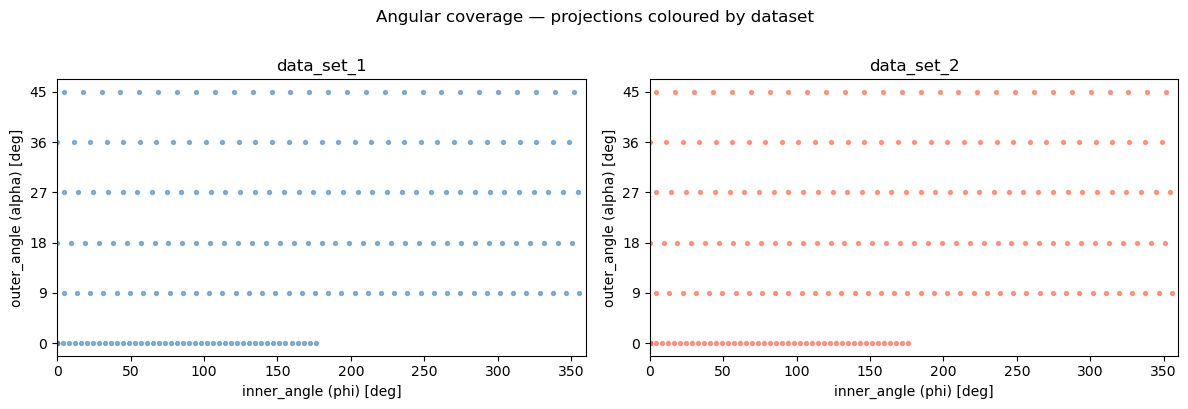

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, inner, outer, color) in zip(axes, [
    ('data_set_1', inner1, outer1, 'steelblue'),
    ('data_set_2', inner2, outer2, 'tomato'),
]):
    ax.scatter(inner, outer, s=8, alpha=0.6, color=color)
    ax.set_xlabel('inner_angle (phi) [deg]')
    ax.set_ylabel('outer_angle (alpha) [deg]')
    ax.set_title(label)
    ax.set_yticks(sorted(set(outer.round(1))))
    ax.set_xlim(0, 360)

plt.suptitle('Angular coverage — projections coloured by dataset', y=1.01)
plt.tight_layout()
plt.show()

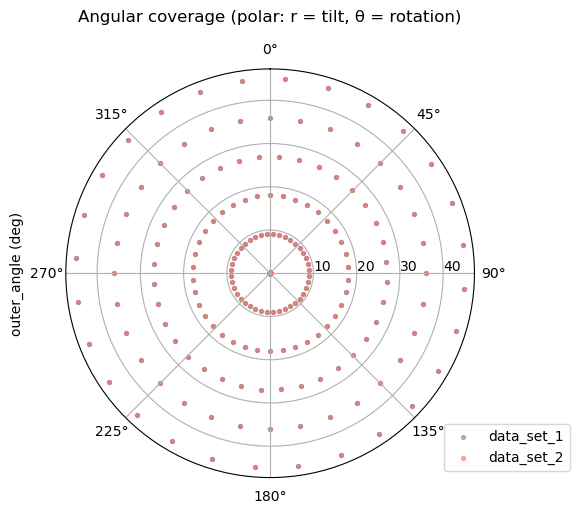

In [6]:
# Polar plot of both datasets together — visualise the missing wedge in 3D
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

for label, inner, outer, color in [
    ('data_set_1', inner1, outer1, 'steelblue'),
    ('data_set_2', inner2, outer2, 'tomato'),
]:
    phi_rad = np.radians(inner)
    # In polar: r = outer_angle (tilt), theta = inner_angle (azimuth)
    ax.scatter(phi_rad, outer, s=8, alpha=0.5, color=color, label=label)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(90)
ax.set_ylabel('outer_angle (deg)', labelpad=30)
ax.legend(loc='lower right', bbox_to_anchor=(1.25, 0.0))
ax.set_title('Angular coverage (polar: r = tilt, θ = rotation)', pad=15)
plt.tight_layout()
plt.show()

## 3. Visualise projections

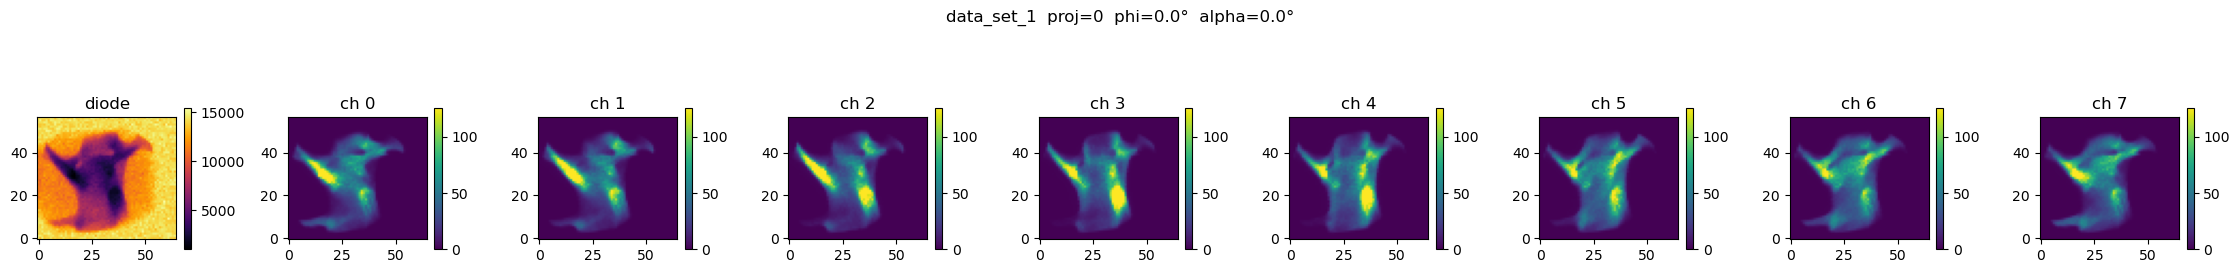

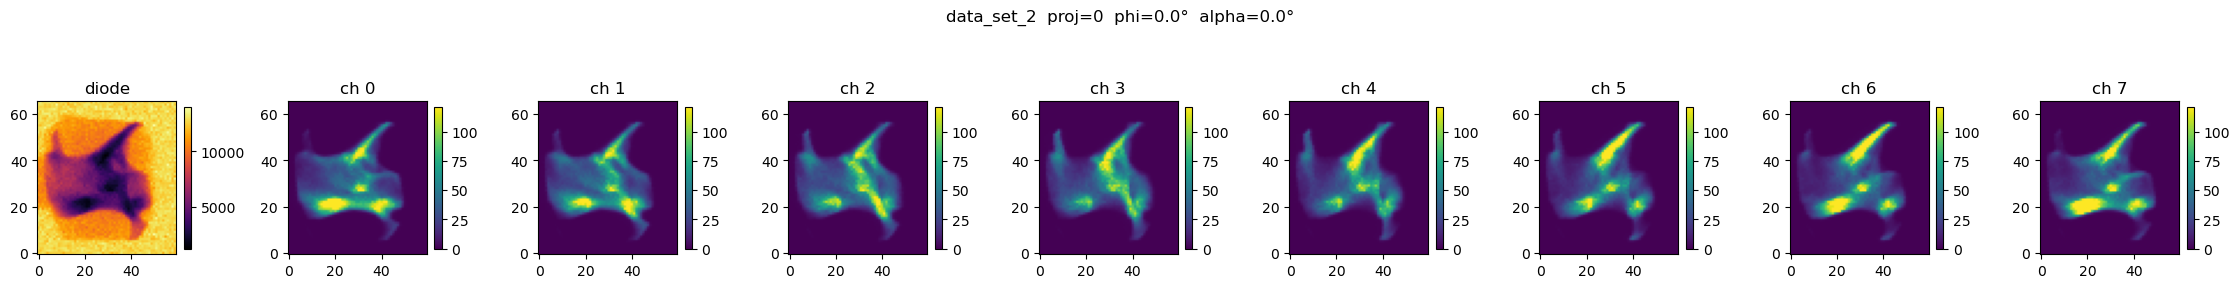

In [7]:
def plot_projection(dc, idx=0, label=''):
    p = dc.projections[idx]
    inner_deg = np.degrees(p.inner_angle)
    outer_deg = np.degrees(p.outer_angle)
    
    n_angles = p.data.shape[-1]
    fig, axes = plt.subplots(1, n_angles + 1, figsize=(2.5*(n_angles+1), 3))
    
    # diode
    im = axes[0].imshow(p.diode.T, origin='lower', cmap='inferno')
    axes[0].set_title('diode')
    plt.colorbar(im, ax=axes[0], fraction=0.046)
    
    # SAXS data per detector angle
    vmax = np.percentile(p.data, 99)
    for i, ax in enumerate(axes[1:]):
        im = ax.imshow(p.data[..., i].T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
        ax.set_title(f'ch {i}')
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    fig.suptitle(f'{label}  proj={idx}  phi={inner_deg:.1f}°  alpha={outer_deg:.1f}°', y=1.01)
    plt.tight_layout()
    plt.show()

plot_projection(dc1, idx=0, label='data_set_1')
plot_projection(dc2, idx=0, label='data_set_2')

## 4. Build combined dataset (ground-truth setup)

The two datasets have different projection shapes:
- `data_set_1`: (65, 57) → pad 9 columns at start → (65, 66)
- `data_set_2`: (60, 66) → pad 5 rows at start → (65, 66)

Then load `full_geometry.geo` for the combined rotation matrices (448 projections).
This mirrors exactly what the original paper notebook does.

In [8]:
import copy

def build_combined_dc(path_ds1, path_ds2, path_geo):
    """Combine both mounts into a single DataContainer for ground-truth reconstruction."""
    combined = DataContainer(str(path_ds1))
    for frame in combined.projections:
        j_pad = 65 - frame.data.shape[0]
        k_pad = 66 - frame.data.shape[1]
        frame.diode   = np.pad(frame.diode,   ((j_pad, 0), (k_pad, 0)))
        frame.data    = np.pad(frame.data,    ((j_pad, 0), (k_pad, 0), (0, 0)))
        frame.weights = np.pad(frame.weights, ((j_pad, 0), (k_pad, 0), (0, 0)))

    dc2_copy = DataContainer(str(path_ds2))
    for frame in dc2_copy.projections:
        j_pad = 65 - frame.data.shape[0]
        k_pad = 66 - frame.data.shape[1]
        frame.diode   = np.pad(frame.diode,   ((j_pad, 0), (k_pad, 0)))
        frame.data    = np.pad(frame.data,    ((j_pad, 0), (k_pad, 0), (0, 0)))
        frame.weights = np.pad(frame.weights, ((j_pad, 0), (k_pad, 0), (0, 0)))

    n = len(dc2_copy.projections)
    for _ in range(n):
        frame = dc2_copy.projections[0]
        del dc2_copy.projections[0]
        combined.projections.append(frame)

    combined.geometry.read(str(path_geo))
    return combined


combined_dc = build_combined_dc(PATH_DS1, PATH_DS2, PATH_GEO_FULL)

print('Combined dataset:')
print(f'  n_projections:    {len(combined_dc.projections)}')
print(f'  volume_shape:     {tuple(combined_dc.geometry.volume_shape)}')
print(f'  projection_shape: {tuple(combined_dc.geometry.projection_shape)}')
print(f'  full_circle_covered: {combined_dc.geometry.full_circle_covered}')
print()
p0 = combined_dc.projections[0]
print(f'  data shape (first proj): {p0.data.shape}')
p_last = combined_dc.projections[-1]
print(f'  data shape (last  proj): {p_last.data.shape}')

INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
Combined dataset:
  n_projections:    448
  volume_shape:     (np.int64(66), np.int64(66), np.int64(66))
  projection_shape: (np.int64(65), np.int64(66))
  full_circle_covered: False

  data sha

## 5. Intensity distribution

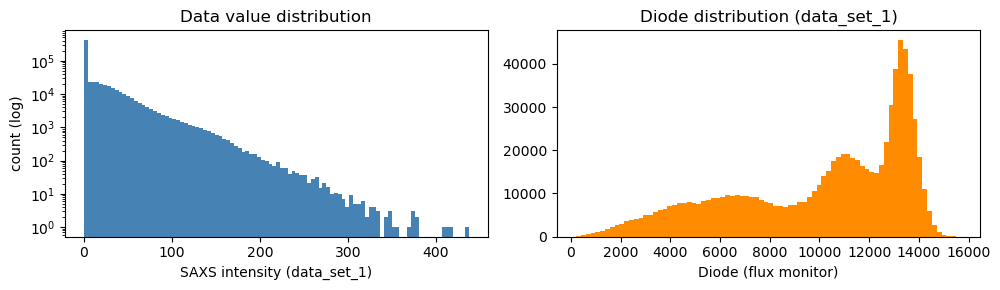

In [25]:
# Collect all data values (subsample for speed)
all_data = np.concatenate([p.data for p in dc1.projections.data[::10]])
diode_vals = np.concatenate([p for p in dc1.diode])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(all_data[all_data > 0], bins=100, log=True, color='steelblue')
axes[0].set_xlabel('SAXS intensity (data_set_1)')
axes[0].set_ylabel('count (log)')
axes[0].set_title('Data value distribution')

axes[1].hist(diode_vals.flatten(), bins=80, color='darkorange')
axes[1].set_xlabel('Diode (flux monitor)')
axes[1].set_title('Diode distribution (data_set_1)')

plt.tight_layout()
plt.show()

## 6. Compatibility with our pipeline

### Quick check: SAXSProjector can be constructed

In [17]:
from mumott.methods.projectors import SAXSProjector

proj1 = SAXSProjector(dc1.geometry)
print('SAXSProjector (ds1):', proj1)

# n_params for LBFGS overflow check (ell_max=8 → 45 SH coefficients)
ELL_MAX = 8
n_coeffs = sum(2*l + 1 for l in range(0, ELL_MAX + 1, 2))  # = 45

for label, vol in [('ds1', dc1.geometry.volume_shape),
                   ('ds2', dc2.geometry.volume_shape),
                   ('combined', combined_dc.geometry.volume_shape)]:
    n_params = int(vol[0]) * int(vol[1]) * int(vol[2]) * n_coeffs
    wa_size_maxcor10 = (2 * 10 + 5) * n_params
    safe = wa_size_maxcor10 < 2**31 - 1
    print(f'  {label:9s}  vol={tuple(vol)}  n_params={n_params/1e6:.1f}M  '
          f'wa_size(maxcor=10)={wa_size_maxcor10/1e9:.2f}G  safe={safe}')

SAXSProjector (ds1): --------------------------------------------------------------------------
                              SAXSProjector                               
--------------------------------------------------------------------------
is_dirty           : False
hash               : f8af47
--------------------------------------------------------------------------
  ds1        vol=(np.int64(57), np.int64(65), np.int64(57))  n_params=9.5M  wa_size(maxcor=10)=0.24G  safe=True
  ds2        vol=(np.int64(66), np.int64(60), np.int64(66))  n_params=11.8M  wa_size(maxcor=10)=0.29G  safe=True
  combined   vol=(np.int64(66), np.int64(66), np.int64(66))  n_params=12.9M  wa_size(maxcor=10)=0.32G  safe=True


## 7. Summary

The Zenodo dataset is **fully compatible** with our pipeline:

- `DataContainer` loads both HDF5 files directly (same mumott format as b411)
- `full_circle_covered` is already `False` — no override needed
- `SAXSProjector` works without modification
- Volumes are small (57–66 voxels) → **no int32 overflow risk** at any `maxcor`

**Key notes for adapting `saxs_naf_benchmark.ipynb`:**
1. Padding target is **(65, 66)** for both datasets (pad at the start, not end)
2. Weights are 3D `(j, k, 8)` with all 1.0 — our pipeline handles this
3. The `full_geometry.geo` format works identically to `combined_geometry.h5` via `geometry.read()`
4. Two distinct mounts (data_set_1 vs data_set_2) mirror the b411 / remount structure
5. No `full_circle_covered` override required (already correct)

**Next step**: adapt `saxs_naf_benchmark.ipynb` to run on this dataset, using
`data_set_1` and `data_set_2` as the two partial scans and `combined_dc` as ground truth.